# Science-image focus look-up table — exploration (v1)

**Author:** Aaron Roodman  
**Date Created:** 2026-09-14  
**Last Modified:** 2026-09-14  
**Status:** In Progress  
**Keywords:** AOS, focus, look-up table, corner wavefront sensor, truss temperature, elevation

## Description

Interactive exploration of the `science_lut` study: a focus Look-Up Table (LUT) for the
Active Optics System (AOS) derived from ordinary **science** exposures rather than from
Full Array Mode (FAM) data. The measured quantity is the optical state recovered at the
four Corner Wavefront Sensors (CWFS), which the Consolidated Database (ConsDB) records
for every science visit.

Key functionality:
1. Read the per-visit table and the fit table written by `code/science_lut/run_science_lut.py`
2. Re-examine the truss-temperature dependence of the uniform-defocus (v-mode-1) amplitude, per band
3. Re-examine the elevation dependence of the temperature-corrected residual
4. Rank the candidate modulating factors of that residual by their partial correlation

**Output:** Figures only; no files are written. The script owns the products.

**Based on:** `../../docs/studies/science_lut.md`, and
`../correlations/corner_z4_vs_temperature_science.ipynb` which this study grew out of.

**Data access:** Reads `output/science_lut/*.parquet` and the value-added database
`output/value_added/aos_efd.duckdb` only — no Engineering Facility Database (EFD) or ConsDB
queries — so it runs on a laptop from synced output.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-14 | Aaron Roodman | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access](#data)
5. [Sample and variants](#sample)
6. [Truss temperature](#truss)
7. [Elevation residual](#elevation)
8. [Candidate modulators](#modulators)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================

study_dir = None          # output/science_lut; None = resolve from the topic directory
db_path = None            # value-added DuckDB file; None = common.efd_db default

bands = ['g', 'r', 'i', 'z', 'y']   # plotted in this order; filter thickness changes the
                                    # camera-hexapod dz LUT, so every fit is per band
variant_ref = None        # optical_state variant to feature; None = the first one present

# Units of the quantities plotted below, stated once here:
#   v-mode-1 amplitude        dimensionless
#   truss_temp_mean_c         deg C
#   altitude_deg              deg (elevation above the horizon)
#   slopes vs truss temp      dimensionless v-mode-1 amplitude per deg C
#   slopes vs elevation       dimensionless v-mode-1 amplitude per deg

<a id='setup'></a>
## Setup & Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A notebook has no __file__, so walk up to the topic directory (the one holding code/).
# This works at any depth, unlike guessing a single level with Path.cwd().parent.
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))      # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))

from common import efd_db
from common.utils import nmad, setup_plotting

setup_plotting()

BAND_COLORS = {'u': 'tab:purple', 'g': 'tab:blue', 'r': 'tab:green',
               'i': 'tab:orange', 'z': 'tab:red', 'y': 'tab:brown'}

print(f'topic directory: {_TOPIC}')

topic directory: /sdf/home/r/roodman/notebooks/rubin-work/aos


<a id='functions'></a>
## Helper Functions

In [3]:
def band_scatter(df, xcol, ycol, xlabel, ylabel, bands=bands, fits=None,
                 stage=None, ax=None, alpha=0.35, s=6):
    """Scatter one quantity against another, coloured by band, with the fitted lines.

    Parameters
    ----------
    df : `pandas.DataFrame`
        Per-visit table; needs `band`, `xcol` and `ycol`.
    xcol, ycol : `str`
        Column names. Units are named by `xlabel` and `ylabel`, not inferred.
    xlabel, ylabel : `str`
        Axis labels, each carrying the quantity name and its unit.
    bands : `list` [`str`], optional
        Bands to draw, in order.
    fits : `pandas.DataFrame`, optional
        Fit table. When given with `stage`, the Huber line for each band is overlaid.
    stage : `str`, optional
        Fit stage to overlay, e.g. ``'truss'``.
    ax : `matplotlib.axes.Axes`, optional
    alpha, s : `float`, optional
        Marker transparency and size.

    Returns
    -------
    ax : `matplotlib.axes.Axes`
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 6))
    for b in bands:
        m = df['band'] == b
        if not m.any():
            continue
        ax.scatter(df.loc[m, xcol], df.loc[m, ycol], s=s, alpha=alpha,
                   color=BAND_COLORS.get(b, 'grey'), label=f'{b}  n={int(m.sum())}')
        if fits is not None and stage is not None:
            f = fits[(fits.stage == stage) & (fits.band == b) & (fits.method == 'huber')]
            if len(f):
                r = f.iloc[0]
                xx = np.linspace(df.loc[m, xcol].min(), df.loc[m, xcol].max(), 20)
                ax.plot(xx, r.intercept + r.slope * xx, '-', lw=1.6,
                        color=BAND_COLORS.get(b, 'grey'))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    return ax


def show_fits(fits, stage, method='huber'):
    """Return the fit rows for one stage, with the slope unit carried in the frame.

    Parameters
    ----------
    fits : `pandas.DataFrame`
        Fit table as written by ``run_science_lut.py``.
    stage : `str`
        One of ``'truss'``, ``'truss_commanded'``, ``'elevation'``, ``'modulator'``.
    method : `str`, optional
        ``'huber'`` (primary) or ``'theilsen'`` (cross-check).

    Returns
    -------
    out : `pandas.DataFrame`
        One row per band, slope in the units named by `slope_unit`.
    """
    cols = ['band', 'n', 'slope', 'slope_err', 'intercept', 'pearson_r',
            'spearman_rho', 'resid_nmad', 'chi2_dof', 'dof', 'slope_unit']
    f = fits[(fits.stage == stage) & (fits.method == method)]
    return f[[c for c in cols if c in f.columns]].reset_index(drop=True)

<a id='data'></a>
## Data Access

Both tables come from `run_science_lut.py`. Nothing here queries the EFD or ConsDB.

In [4]:
sd = Path(study_dir) if study_dir else (_TOPIC / 'output' / 'science_lut')
pv = pd.read_parquet(sd / 'science_lut.parquet')
fits_all = pd.read_parquet(sd / 'science_lut_fits.parquet')

print(f'per-visit rows: {len(pv)}   columns: {pv.shape[1]}')
print(f'fit rows:       {len(fits_all)}')
print(f"day_obs range:  {int(pv.day_obs.min())} to {int(pv.day_obs.max())} "
      f"({pv.day_obs.nunique()} nights)")
print(f"variants:       {sorted(pv.variant.unique())}")

per-visit rows: 806   columns: 124
fit rows:       85
day_obs range:  20251102 to 20260302 (2 nights)
variants:       ['v50_34__batoid__consdb_v1']


<a id='sample'></a>
## Sample and variants

The `variant` column names the `optical_state` recovery used for the measured term: a
combination of degree-of-freedom (DOF) scheme, intrinsic-wavefront route, and optical path
difference (OPD) version. The registry in the database says what each one is.

In [5]:
reg = efd_db.variants(db_path=db_path)
display(reg)

vref = variant_ref or sorted(pv.variant.unique())[0]
d = pv[pv.variant == vref].copy()
print(f'featured variant: {vref}   n = {len(d)} visits')

display(d.groupby(['science_program', 'band']).size().rename('n_visits').reset_index())

,variant_id,scheme,n_dof,n_modes,intrinsic_route,intrinsic_ref,opd_source,opd_version,ofc_config_version,created_at,notes
0,v22_12__batoid__consdb_v1,22_12,22,12,batoid,ofc_v13,consdb_ccdvisit1_quicklook,consdb_v1,v13,2026-09-14 17:03:54.990670,None
1,v50_34__batoid__consdb_v1,50_34,50,34,batoid,ofc_v13,consdb_ccdvisit1_quicklook,consdb_v1,v13,2026-09-14 17:00:21.952763,None


featured variant: v50_34__batoid__consdb_v1   n = 806 visits


,science_program,band,n_visits
0,BLOCK-365,i,59
1,BLOCK-365,r,59
2,BLOCK-365,y,60
3,BLOCK-365,z,60
4,BLOCK-407,y,303
5,BLOCK-421,r,2
6,BLOCK-421,y,208
7,BLOCK-421,z,55


In [6]:
# The three v-mode-1 terms. v1_total = v1_lut + v1_trim + MEASURED_SIGN * v1_meas with
# MEASURED_SIGN = -1: the commanded motion opposes the measured focus error, so a surviving
# measured residual enters with the sign that cancels it.
terms = ['v1_lut', 'v1_trim', 'v1_lut_trim', 'v1_meas', 'v1_total']
summary = pd.DataFrame({
    'n_finite': [int(np.isfinite(d[c]).sum()) for c in terms],
    'median': [np.nanmedian(d[c]) for c in terms],
    'nmad': [nmad(d[c].to_numpy(float)) for c in terms],
}, index=terms)
summary.index.name = 'term (dimensionless v-mode-1 amplitude)'
display(summary)

,n_finite,median,nmad
term (dimensionless v-mode-1 amplitude),,,
v1_lut,806,1.862116,1.129938
v1_trim,806,0.234336,0.186324
v1_lut_trim,806,2.497234,0.255912
v1_meas,799,0.010804,0.010823
v1_total,799,2.488133,0.246263


<a id='truss'></a>
## Truss temperature

The uniform-defocus content of the **commanded** optical state tracks Telescope Mount
Assembly (TMA) truss temperature, consistent with thermal expansion of a steel truss. The
FAM commanded value for comparison is **+0.09634 dimensionless v-mode-1 amplitude per °C**
from `code/correlations/run_dz14_truss.py`.

Read the **per-band** rows. A band-pooled fit appears as `all_pooled` for completeness but is
not a physical slope: the camera-hexapod dz look-up table is filter-dependent, so pooling
leaves a band-to-band focus offset that biases a single straight line.

In [7]:
f = fits_all[fits_all.variant == vref]
print('v1_total against truss temperature  [dimensionless v-mode-1 amplitude per deg C]')
display(show_fits(f, 'truss'))
print('Theil-Sen cross-check (non-parametric in the slope):')
display(show_fits(f, 'truss', method='theilsen'))
print('commanded only (v1_lut + v1_trim), the term directly comparable with the FAM value:')
display(show_fits(f, 'truss_commanded'))

v1_total against truss temperature  [dimensionless v-mode-1 amplitude per deg C]


,band,n,slope,slope_err,intercept,pearson_r,spearman_rho,resid_nmad,chi2_dof,dof,slope_unit
0,r,55,0.224903,0.015261,-1.572801,-0.758876,0.526623,0.013316,173.552160,53.0,dimensionless v-mode-1 amplitude per deg C
1,i,55,-0.018259,0.020418,2.189355,-0.076912,-0.052453,0.009964,1.443455,53.0,dimensionless v-mode-1 amplitude per deg C
2,z,109,-0.156052,0.006940,4.346927,-0.729437,-0.886239,0.031840,4.503715,107.0,dimensionless v-mode-1 amplitude per deg C
3,y,545,0.083908,0.003623,1.745880,0.684741,0.631346,0.151322,1.132881,543.0,dimensionless v-mode-1 amplitude per deg C
4,all_pooled,764,-0.002011,0.005615,2.525430,-0.177797,-0.213126,0.243539,2.734489,762.0,dimensionless v-mode-1 amplitude per deg C


Theil-Sen cross-check (non-parametric in the slope):


,band,n,slope,slope_err,intercept,pearson_r,spearman_rho,resid_nmad,chi2_dof,dof,slope_unit
0,r,55,0.276407,0.052312,-2.215187,NaN,NaN,0.009475,NaN,NaN,dimensionless v-mode-1 amplitude per deg C
1,i,55,-0.013857,0.047098,2.131356,NaN,NaN,0.010258,NaN,NaN,dimensionless v-mode-1 amplitude per deg C
2,z,109,-0.170735,0.017160,4.582276,NaN,NaN,0.033031,NaN,NaN,dimensionless v-mode-1 amplitude per deg C
3,y,545,0.078281,0.008752,1.898174,NaN,NaN,0.156467,NaN,NaN,dimensionless v-mode-1 amplitude per deg C
4,all_pooled,764,-0.040140,0.022357,2.967018,NaN,NaN,0.287771,NaN,NaN,dimensionless v-mode-1 amplitude per deg C


commanded only (v1_lut + v1_trim), the term directly comparable with the FAM value:


,band,n,slope,slope_err,intercept,pearson_r,spearman_rho,resid_nmad,chi2_dof,dof,slope_unit
0,r,55,0.186179,0.017498,-1.056951,-0.763494,0.508081,0.015536,118.244399,53.0,dimensionless v-mode-1 amplitude per deg C
1,i,55,0.000058,0.020003,1.966555,-0.077282,0.129293,0.013860,0.894762,53.0,dimensionless v-mode-1 amplitude per deg C
2,z,109,-0.161727,0.006959,4.433063,-0.744721,-0.884645,0.035077,3.603186,107.0,dimensionless v-mode-1 amplitude per deg C
3,y,552,0.089677,0.003620,1.691507,0.705526,0.646359,0.155648,1.074547,550.0,dimensionless v-mode-1 amplitude per deg C
4,all_pooled,771,0.003802,0.005645,2.471500,-0.152506,-0.180604,0.246530,2.681975,769.0,dimensionless v-mode-1 amplitude per deg C


/lscratch/roodman/ipykernel_1248197/1027346737.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


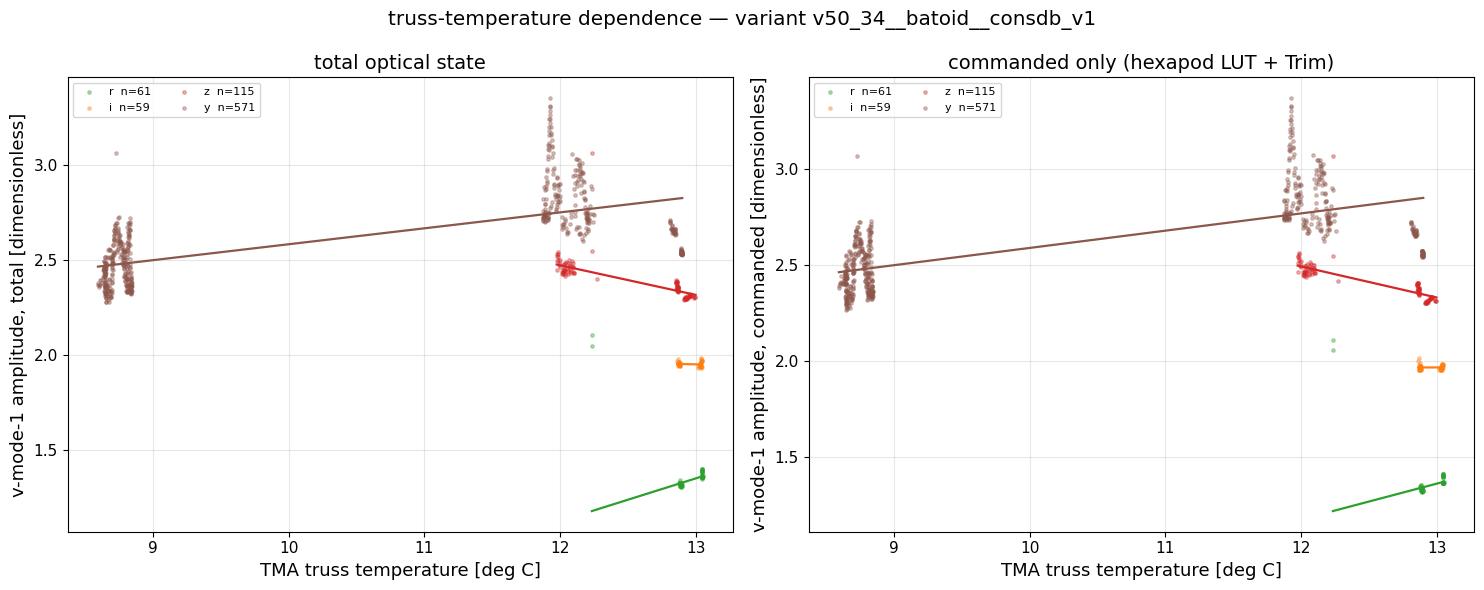

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
band_scatter(d, 'truss_temp_mean_c', 'v1_total',
             'TMA truss temperature [deg C]',
             'v-mode-1 amplitude, total [dimensionless]',
             fits=f, stage='truss', ax=axes[0])
axes[0].set_title('total optical state')
band_scatter(d, 'truss_temp_mean_c', 'v1_lut_trim',
             'TMA truss temperature [deg C]',
             'v-mode-1 amplitude, commanded [dimensionless]',
             fits=f, stage='truss_commanded', ax=axes[1])
axes[1].set_title('commanded only (hexapod LUT + Trim)')
fig.suptitle(f'truss-temperature dependence — variant {vref}')
fig.tight_layout()

<a id='elevation'></a>
## Elevation residual

With the truss-temperature relation removed, a substantial elevation dependence remains —
larger than the gravitational flexure the existing hexapod LUT already compensates. This is
the effect the study exists to characterize.

truss-corrected residual against elevation  [dimensionless v-mode-1 amplitude per deg]


,band,n,slope,slope_err,intercept,pearson_r,spearman_rho,resid_nmad,chi2_dof,dof,slope_unit
0,r,55,-0.019506,0.000768,1.506390,-0.962137,0.043290,0.060685,0.599011,53.0,dimensionless v-mode-1 amplitude per deg eleva...
1,i,55,-0.000146,0.000344,0.011033,-0.015592,-0.119048,0.009322,1.654733,53.0,dimensionless v-mode-1 amplitude per deg eleva...
2,z,109,-0.003168,0.000290,0.227810,-0.688605,-0.705505,0.022700,5.549696,107.0,dimensionless v-mode-1 amplitude per deg eleva...
3,y,545,-0.015076,0.000354,0.931942,-0.873755,-0.852503,0.068386,1.312827,543.0,dimensionless v-mode-1 amplitude per deg eleva...
4,all_pooled,764,-0.008661,0.000351,0.568762,-0.701206,-0.603400,0.100928,1.075544,762.0,dimensionless v-mode-1 amplitude per deg eleva...


,band,n,slope,slope_err,intercept,pearson_r,spearman_rho,resid_nmad,chi2_dof,dof,slope_unit
0,r,55,-0.000054,0.002020,0.001475,NaN,NaN,0.013748,NaN,NaN,dimensionless v-mode-1 amplitude per deg eleva...
1,i,55,-0.000245,0.000724,0.017771,NaN,NaN,0.010292,NaN,NaN,dimensionless v-mode-1 amplitude per deg eleva...
2,z,109,-0.003485,0.000746,0.239587,NaN,NaN,0.024234,NaN,NaN,dimensionless v-mode-1 amplitude per deg eleva...
3,y,545,-0.014549,0.000686,0.891250,NaN,NaN,0.067372,NaN,NaN,dimensionless v-mode-1 amplitude per deg eleva...
4,all_pooled,764,-0.007759,0.000878,0.508656,NaN,NaN,0.098226,NaN,NaN,dimensionless v-mode-1 amplitude per deg eleva...


Text(0.5, 1.0, 'elevation dependence of the truss-corrected residual — v50_34__batoid__consdb_v1')

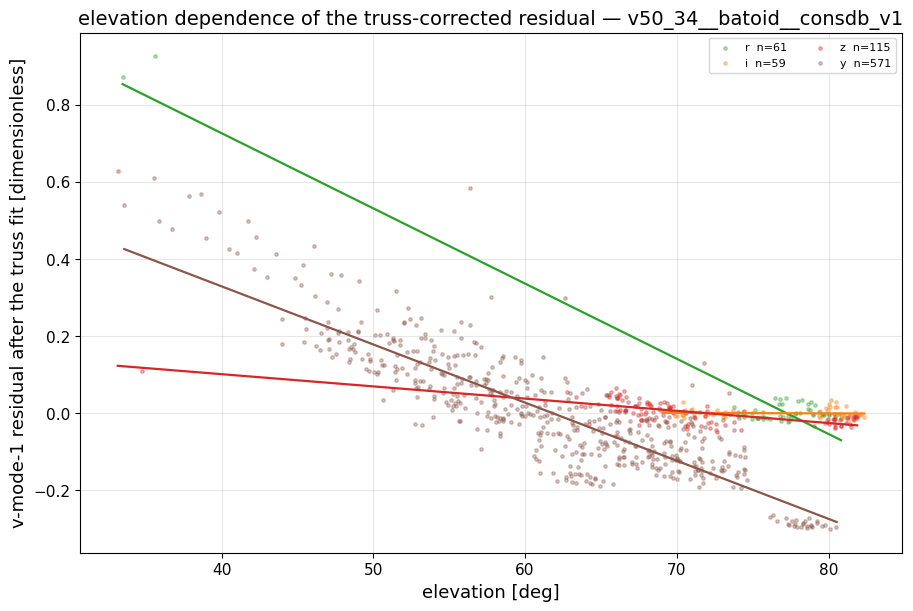

In [9]:
print('truss-corrected residual against elevation  '
      '[dimensionless v-mode-1 amplitude per deg]')
display(show_fits(f, 'elevation'))
display(show_fits(f, 'elevation', method='theilsen'))

band_scatter(d, 'altitude_deg', 'v1_resid_truss',
             'elevation [deg]',
             'v-mode-1 residual after the truss fit [dimensionless]',
             fits=f, stage='elevation')
plt.title(f'elevation dependence of the truss-corrected residual — {vref}')

<a id='modulators'></a>
## Candidate modulators

Each candidate is added as a second regressor on the temperature-corrected residual, at fixed
elevation. What matters is the **partial** correlation at fixed elevation and the change in
`chi2/dof`: a negative `delta_chi2_dof` means adding the factor improved the fit.

`day_obs_min` and `day_obs_max` give the sub-range over which each column actually exists, so
a factor deployed part-way through the range is not passed off as covering the whole sample. A
factor that is constant over the selection has no contrast and is skipped by the script rather
than fitted.

In [10]:
mod = f[f.stage == 'modulator'].copy()
cols = ['modulator_label', 'band', 'n', 'slope', 'slope_err', 'x_unit',
        'partial_pearson_r', 'chi2_dof_elevation_only', 'chi2_dof_with_modulator',
        'delta_chi2_dof', 'day_obs_min', 'day_obs_max']

# Rank by how much each factor improves the fit, using the band-pooled row — legitimate here
# because the residual is already band-corrected by the per-band truss and elevation fits.
rank = (mod[mod.band == 'all'][['modulator_label', 'n', 'partial_pearson_r',
                                'delta_chi2_dof', 'day_obs_min', 'day_obs_max']]
        .sort_values('delta_chi2_dof')
        .reset_index(drop=True))
print('candidate modulators ranked by delta chi2/dof (most negative = best improvement):')
display(rank)

candidate modulators ranked by delta chi2/dof (most negative = best improvement):


,modulator_label,n,partial_pearson_r,delta_chi2_dof,day_obs_min,day_obs_max
0,commanded hexapod moves so far this night,764,-0.250848,-0.418845,20251102.0,20260302.0
1,M1M3 z thermal gradient,764,-0.569245,-0.188263,20251102.0,20260302.0
2,cumulative |hexapod dz| since night start,764,-0.279035,-0.183122,20251102.0,20260302.0
3,weather-station wind speed,764,-0.267764,-0.176797,20251102.0,20260302.0
4,trailing-window |hexapod dz|,764,-0.179932,-0.151845,20251102.0,20260302.0
5,M1M3 y thermal gradient,764,-0.379136,-0.130463,20251102.0,20260302.0
6,M1M3 x thermal gradient,764,0.137499,-0.061748,20251102.0,20260302.0
7,M1M3 radial thermal gradient,764,0.181235,-0.032470,20251102.0,20260302.0
8,wind direction relative to azimuth (0 = into t...,764,0.101459,0.050812,20251102.0,20260302.0
9,salIndex 126 sonic anemometer speed magnitude,464,0.112130,0.066887,20260302.0,20260302.0


In [11]:
# Per-band detail for the best few candidates.
for lab in rank.modulator_label.head(3):
    print(f'\n{lab}')
    display(mod[mod.modulator_label == lab][cols].reset_index(drop=True))


commanded hexapod moves so far this night


,modulator_label,band,n,slope,slope_err,x_unit,partial_pearson_r,chi2_dof_elevation_only,chi2_dof_with_modulator,delta_chi2_dof,day_obs_min,day_obs_max
0,commanded hexapod moves so far this night,r,55,0.000487,0.000030,count,0.722292,0.599011,0.869521,0.270509,20251102.0,20260302.0
1,commanded hexapod moves so far this night,i,55,0.000015,0.000027,count,0.338355,1.654733,1.452554,-0.202178,20251102.0,20260302.0
2,commanded hexapod moves so far this night,z,109,0.000048,0.000011,count,0.341622,5.549696,5.389201,-0.160495,20251102.0,20260302.0
3,commanded hexapod moves so far this night,y,545,-0.000213,0.000022,count,-0.370876,1.312827,1.220025,-0.092803,20251102.0,20260302.0
4,commanded hexapod moves so far this night,all,764,-0.000096,0.000014,count,-0.250848,1.802598,1.383753,-0.418845,20251102.0,20260302.0



M1M3 z thermal gradient


,modulator_label,band,n,slope,slope_err,x_unit,partial_pearson_r,chi2_dof_elevation_only,chi2_dof_with_modulator,delta_chi2_dof,day_obs_min,day_obs_max
0,M1M3 z thermal gradient,r,55,-0.740495,0.046656,deg C per m,-0.928772,0.599011,1.519672,0.920661,20251102.0,20260302.0
1,M1M3 z thermal gradient,i,55,-0.041037,0.035028,deg C per m,-0.480418,1.654733,1.084217,-0.570516,20251102.0,20260302.0
2,M1M3 z thermal gradient,z,109,0.058049,0.013805,deg C per m,0.189670,5.549696,5.351357,-0.198338,20251102.0,20260302.0
3,M1M3 z thermal gradient,y,545,-0.591768,0.018436,deg C per m,-0.777695,1.312827,1.610655,0.297827,20251102.0,20260302.0
4,M1M3 z thermal gradient,all,764,-0.315258,0.017136,deg C per m,-0.569245,1.802598,1.614335,-0.188263,20251102.0,20260302.0



cumulative |hexapod dz| since night start


,modulator_label,band,n,slope,slope_err,x_unit,partial_pearson_r,chi2_dof_elevation_only,chi2_dof_with_modulator,delta_chi2_dof,day_obs_min,day_obs_max
0,cumulative |hexapod dz| since night start,r,55,1.401674e-05,8.491312e-07,um,0.750100,0.599011,0.818711,0.219699,20251102.0,20260302.0
1,cumulative |hexapod dz| since night start,i,55,2.931216e-07,7.462868e-07,um,0.265892,1.654733,1.452870,-0.201863,20251102.0,20260302.0
2,cumulative |hexapod dz| since night start,z,109,1.470935e-06,3.507399e-07,um,0.365255,5.549696,5.362725,-0.186970,20251102.0,20260302.0
3,cumulative |hexapod dz| since night start,y,545,-7.571580e-07,7.743742e-08,um,-0.310226,1.312827,1.322147,0.009319,20251102.0,20260302.0
4,cumulative |hexapod dz| since night start,all,764,-5.160231e-07,5.984681e-08,um,-0.279035,1.802598,1.619476,-0.183122,20251102.0,20260302.0


Text(0.5, 1.0, 'best-ranked modulator: n_moves_night  (partial r|elevation = -0.251, n = 764)')

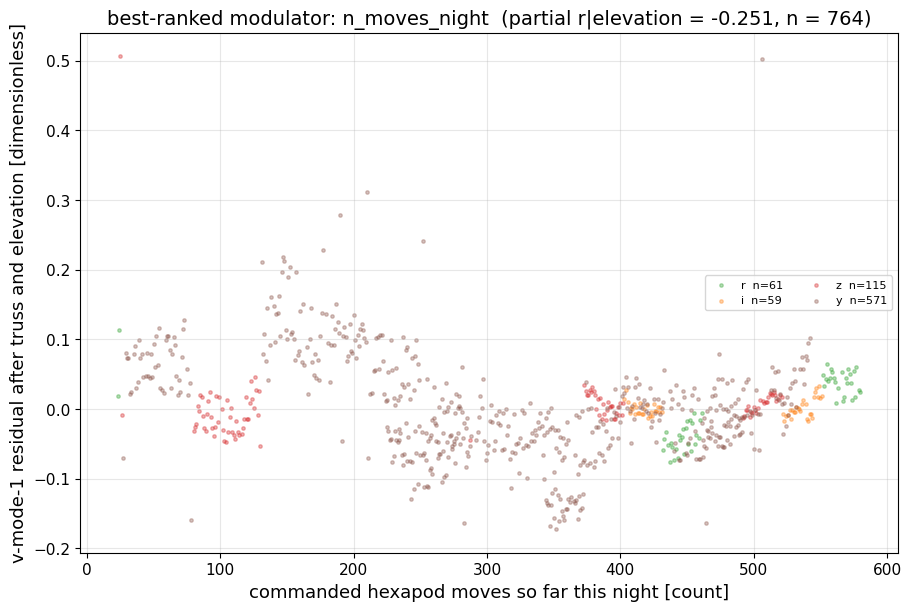

In [12]:
# The elevation-corrected residual against the top-ranked factor, per band.
best = mod[mod.band == 'all'].sort_values('delta_chi2_dof').iloc[0]
bcol = best.modulator
band_scatter(d, bcol, 'v1_resid_truss_elev',
             f'{best.modulator_label} [{best.x_unit}]',
             'v-mode-1 residual after truss and elevation [dimensionless]')
plt.title(f'best-ranked modulator: {bcol}  '
          f'(partial r|elevation = {best.partial_pearson_r:+.3f}, n = {int(best.n)})')